# Quartic OU with white Gaussian noise — the simplest nonlinear baseline

**Showcases:** the most elementary *nonlinear* stochastic process the pipeline handles — an Ornstein–Uhlenbeck variable with a cubic restoring force driven by **white** Gaussian noise. A single physical field, no Markovian embedding, so the diagrammatics run on the bare white-noise action and the loop integrals stay cheap (2-loop here completes in a fraction of a second). This is the white-noise sibling of the `ou_quartic_colored` example; comparing the two isolates exactly what the finite-$\tau_c$ embedding adds.

$$\dot x = -\mu\,x - \varepsilon\,x^3 + \xi,\qquad \langle\xi(t)\,\xi(t')\rangle = 2D\,\delta(t-t').$$

At $\mu>0$ the mean-field saddle is $x^\*=0$ (single well); $\mu<0$ is the genuine double well. The cubic term suppresses the equal-time variance below the linear value $D/\mu$; the loop corrections capture that shift.

## 0. Setup

In [1]:
%matplotlib inline
import os, sys, time
import numpy as np
import matplotlib.pyplot as plt
# depth-robust repo root: walk up until the 'pipeline' package is found
_root = os.path.abspath('')
while _root != os.path.dirname(_root) and not os.path.isdir(os.path.join(_root, 'pipeline')):
    _root = os.path.dirname(_root)
sys.path.insert(0, _root)
sys.path.insert(0, os.path.join(_root, 'notebooks'))
os.chdir(os.path.join(_root, 'notebooks'))  # cwd=notebooks/ for models/ data paths
import daedalus as dd

## 1. The model

`dd.describe_model` prints the structure straight from the theory file `theories/ou_quartic.theory.py`. A **single** physical field $x$ with white-noise drive — note there is just one fluctuation field `dx` (contrast the colored example, where a Markovian embedding adds an auxiliary `dxi`).

In [2]:
THEORY = 'ou_quartic'
model, mod = dd.load_theory(THEORY)
dd.describe_model(model, mod)
print('\nphysical fields:', dd.field_names(model))

────────────────────────────────────────────────────────────────────────
  OU Quartic (white noise)
────────────────────────────────────────────────────────────────────────
Domain         : temporal ODE (time-only)
Fields         : x — variable
Response fields: xt
Parameters     :
    mu = 1.0  (positive)
    eps = 0.02  (positive)
    D = 1.0  (positive)
Mean-field saddle (solved by the pipeline): xstar
Governing eqn  : (Dt+mu)*x[i] = -eps*x[i]^3
Suggested run  : k=2, max_ell=0

The simplest nonlinear stochastic process in the framework: an
Ornstein–Uhlenbeck variable with a cubic restoring nonlinearity, driven by
*white* Gaussian noise,

    dx/dt = -mu*x - eps*x^3 + xi,    <xi(t) xi(t')> = 2 D delta(t - t').

This is the white-noise sibling of ``ou_quartic_colored`` — a SINGLE physical
field, no finite-tau_c Markovian embedding — so every diagram runs on the bare
white-noise system and the loop integrals stay cheap.  At mu>0 the mean-field
saddle is x*=0 (single well); mu<0 is the g

## 2. The pipeline → theoretical cumulants

One `dd.run` drives the whole MSR-JD chain (enumerate diagrams → propagator → mean-field saddle → loop integrals → cumulant). We request the autocorrelator $C_{xx}(\tau)=\langle x(0)\,x(\tau)\rangle$ via `external_fields=[('dx',1),('dx',1)]` and go to **2-loop** (`max_ell=2`). The plot is the **theory only** — the simulation is added in §3.

Parameters sit in the mildly-perturbative single-well regime ($\mu=1>0$, $\varepsilon=0.02$, saddle $x^\*=0$): the loop expansion parameter $g_{\rm eff}\approx\varepsilon D/\mu^2=0.02$, so tree + 1-loop + 2-loop converge quickly.

In [3]:
cfg = dd.Config(
    k=2, max_ell=2,                          # C_xx(τ), tree + 1-loop + 2-loop
    external_fields=[('dx', 1), ('dx', 1)],  # physical field autocorrelator
    parameters={'mu': 1.0, 'eps': 0.02, 'D': 1.0},
    tau_grid=(-8.0, 8.0, 33),
    parallel=False,                          # serial (no fork in a notebook)
#   ─── optional · uncomment any (swap the leading # for a space) · dd.config_options() lists all ───
#   output='moment',              # 'cumulant'(default) | 'moment' | 'central_moment'
#   kpoint_base_lags=[0.0, 0.0],  # k≥3 temporal: fix the non-swept legs (slices cross here)
#   kpoint_full_grid=True,        # k≥3 temporal: full (k−1)-D tensor C(τ₁,…) vs axis slices
#   dyson_order=2, reference_diffusion=1.0,   # coupled unequal-D Dyson dressing
#   fixed_point_index=0,          # multi-root saddle: which stable root (0, 1, …)
#   mf_dae_n_starts=64, mf_dae_seed_box=None, # saddle solver: multi-start / seed box
#   n_workers=4,                  # worker count (spatial threads; macOS temporal: outside Jupyter)
#   verbose=True,                 # print backend progress
#   show_orders='incremental',    # 'cumulative'(default) | 'incremental' | 'total'
#   logy=True,                    # log-scale the y axis
#   components=None,              # which (i,j)/slice to draw (multi-field)
#   figsize=(7.5, 4.6),           # matplotlib figure size
#   title='...',                  # override the plot title
#   save='fig.png',               # path to savefig
)


theory : 'OU Quartic (white noise)'
k      : 2    max_ell : 2
fields : ['dx']   spatial_dim : 0


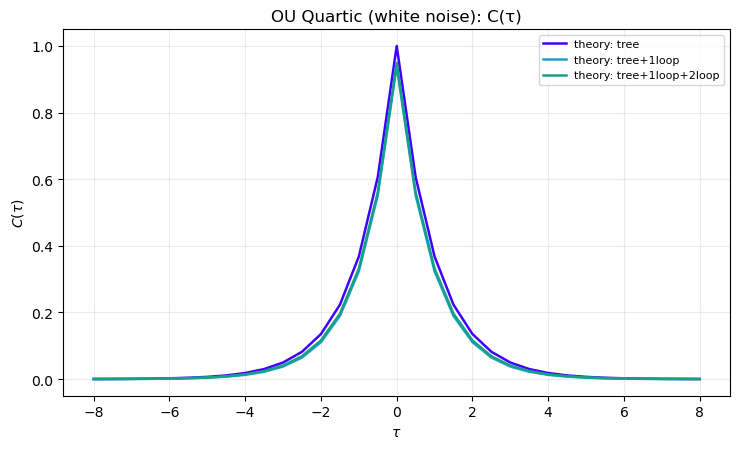

In [4]:
res = dd.run(model, cfg, mod)
print(dd.summary(res))
dd.plot_cumulant(res, cfg, model)   # theory only
plt.show()

## 3. Independent simulation

A direct Euler–Maruyama integration of the white-noise SDE — written from scratch, no reference to the diagrammatics. We integrate $x$ forward, bin it **finely** (bin width $\ll 1/\mu$, so the bin-averaged variance equals the instantaneous $C_{xx}(0)$ the theory reports), and estimate the connected $C_{xx}(\tau)$. Overlaying it on the pipeline curve is the validation.

sim took 8.1s  (3 runs × T=2e+05)
C_xx(0):  tree = 1.0000   tree+loops = 0.9496   sim = 0.9512 ± 0.0011


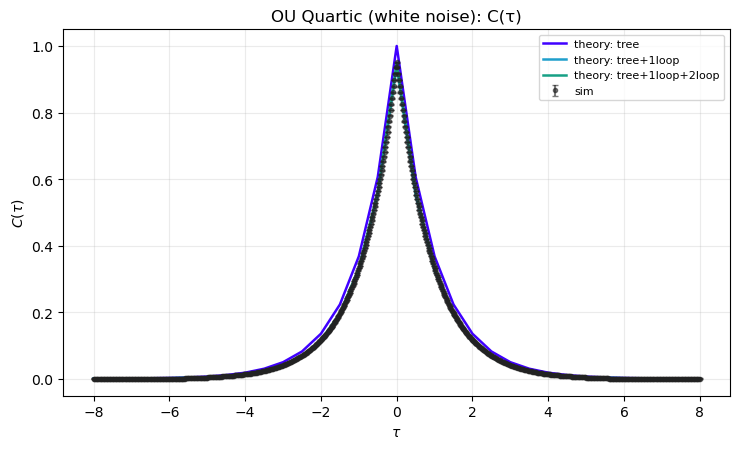

In [5]:
# Independent SDE simulation (Euler–Maruyama, white Gaussian noise) — NOT the pipeline.
from models.ou_langevin_sim_numba import sim_ou_quartic_numba
from models.cumulant_estimator import estimate_kpoint_slices
fp = res['_resolved']['parameters']          # same physics as the theory run
# Cast to plain Python floats — under the Sage kernel the resolved params are
# Sage ring elements, which numba's njit cannot type.
mu = float(fp['mu']); eps = float(fp['eps']); D = float(fp['D'])

# Discretization.  dt_sim ≪ relaxation time 1/mu; bin FINELY (dt_bin ≪ 1/mu)
# so the bin-averaged variance is effectively the instantaneous C_xx(0) — a
# coarse bin would smooth fluctuations and bias C_xx(0) low.
dt_sim, dt_bin = float(0.01), float(0.02)
T_sim          = float(2.0e5)              # ~1-min run for clean error bars
N_RUNS         = int(3)
tau_max        = float(np.max(np.abs(res['tau_grid'])))
n_steps        = int(T_sim / dt_sim)
bin_size_steps = int(max(round(float(dt_bin / dt_sim)), 1))
dt_bin_eff     = float(bin_size_steps * dt_sim)
n_bins         = int(n_steps // bin_size_steps)
max_lag_bins   = int(tau_max / dt_bin_eff)
x_init         = float(0.0)

# k-aware estimator (here k=2 → a single autocorrelation slice).
k         = int(res['_resolved']['k'])
base      = list(cfg.kpoint_base_lags) if cfg.kpoint_base_lags else [0.0]*(k-1)
base_bins = [int(round(b / dt_bin_eff)) for b in base]
pop_indices = [0]*k
field_types = ['dv']*k

_ = sim_ou_quartic_numba(int(1000), dt_sim, mu, eps, D, x_init,
                         bin_size_steps, int(100), int(0))    # JIT warmup
rng_base = int(np.random.SeedSequence().generate_state(1)[0]) % (2**31)
C_runs = []
t0 = time.perf_counter()
for r in range(N_RUNS):
    x_bins = sim_ou_quartic_numba(n_steps, dt_sim, mu, eps, D, x_init,
                                  bin_size_steps, n_bins, int(rng_base + r))
    tau_sim, Cj = estimate_kpoint_slices(
        dt_bin_eff, pop_indices, field_types, base_bins,
        int(max_lag_bins), voltage_bins=x_bins)              # Cj: (k-1, n_tau)
    C_runs.append(np.asarray(Cj).real)
C_arr = np.array(C_runs)
C_sim = C_arr.mean(axis=0)
C_err = C_arr.std(axis=0, ddof=1) / np.sqrt(N_RUNS)
sim   = {'tau': tau_sim, 'C': C_sim, 'C_err': C_err}
print('sim took %.1fs  (%d runs × T=%.0g)' % (time.perf_counter() - t0, N_RUNS, T_sim))

i0 = int(np.argmin(np.abs(np.asarray(res['tau_grid']))))
js = int(np.argmin(np.abs(tau_sim)))
C0_tree = np.real(res['C_tau_by_ell'][0])[i0]
C0_loop = np.real(res['C_tau'])[i0]
print('C_xx(0):  tree = %.4f   tree+loops = %.4f   sim = %.4f ± %.4f'
      % (C0_tree, C0_loop, C_sim[0][js], C_err[0][js]))
dd.plot_cumulant(res, cfg, model, sim=sim)
plt.show()

## Summary

White Gaussian noise enters the MSR-JD machinery directly (the noise vertex is the local $-D\,\tilde x^2$ term), so no embedding is needed and the single field keeps the diagram count — and the loop integrals — small. The cubic nonlinearity pulls the equal-time variance $C_{xx}(0)$ below the linear value $D/\mu=1$; the tree estimate already sees most of this, and the 1- and 2-loop self-energy corrections move it onto the direct simulation. Swapping `parameters` toward $\mu\to0$ (or $\mu<0$) stresses the perturbative series and is the natural next experiment.